<a href="https://colab.research.google.com/github/iandrukhiv-cell/addressbook-python/blob/main/%D0%90%D0%BD%D0%B4%D1%80%D1%83%D1%85%D1%96%D0%B2_%D0%86%D0%BB%D0%BE%D0%BD%D0%B0_%D0%92%D0%BE%D0%BB%D0%BE%D0%B4%D0%B8%D0%BC%D0%B8%D1%80%D1%96%D0%B2%D0%BD%D0%B0_%D0%9E%D1%81%D0%BD%D0%BE%D0%B2%D0%B8_%D0%B0%D0%BD%D0%B0%D0%BB%D1%96%D1%82%D0%B8%D0%BA%D0%B8_%D0%94%D0%975.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Завдання №1

Створюємо масив часу відповідно до кількості вимірювань.

In [33]:
import numpy as np

speed = np.array([25, 35, 45, 30, 60, 120, 100, 100, 70, 75, 80, 65])
time = np.linspace(0, 11, len(speed))

Будуємо графік швидкості від часу.

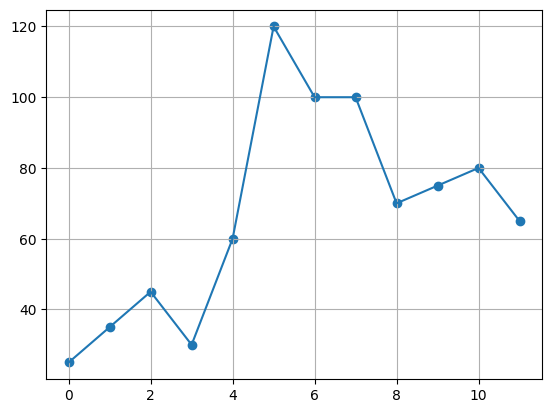

In [34]:
import matplotlib.pyplot as plt

plt.scatter(time, speed)
plt.plot(time, speed)
plt.grid()
plt.show()

Робимо плавну функцію (cubic).

In [35]:
from scipy.interpolate import interp1d

f = interp1d(time, speed, kind='cubic')
time_new = np.linspace(0, 11, 10000)
speed_new = f(time_new)

Будуємо згладжений графік.

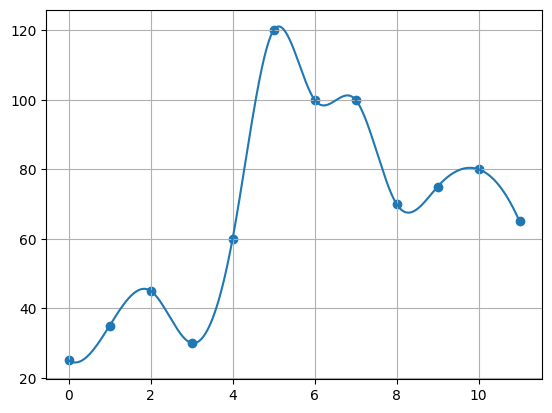

In [36]:
plt.plot(time_new, speed_new)
plt.scatter(time, speed)
plt.grid()
plt.show()

Обчислюємо шлях.

In [37]:
from scipy.integrate import quad

result, _ = quad(f, 0, 11)
print(result)

761.586477590826


Те саме для quadratic.

In [38]:
f2 = interp1d(time, speed, kind='quadratic')
result2, _ = quad(f2, 0, 11)
print(result2)

762.7374192196539


# Завдання №2

In [39]:
from scipy.optimize import minimize

def fence_length(x):
    a, b = x
    return a + 2 * b

def area_constraint(x):
    a, b = x
    return a * b - 1000

result = minimize(
    fence_length,
    x0=[50, 20],
    bounds=[(0, None), (0, None)],
    constraints={"type": "eq", "fun": area_constraint}
)

a, b = result.x

print("a =", a)
print("b =", b)
print("Мінімальна довжина огорожі =", result.fun)

a = 44.72136113496446
b = 22.36067898245687
Мінімальна довжина огорожі = 89.4427190998782


Оптимальні розміри області приблизно a = 44.72 м, b = 22.36 м. Мінімальна довжина огорожі приблизно 89.44 м.

# Завдання №3

Задаємо початкові параметри моделі та часовий проміжок.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit, minimize_scalar

alpha = 0.5
beta = 0.3
N = 1000000

S0 = 990000
I0 = 7000
R0 = 3000

t = np.linspace(0, 25, 1000)

Розв’язуємо систему диференціальних рівнянь для S(t), I(t), R(t).

In [41]:
def sir_model(y, t):
    S, I, R = y
    dSdt = -alpha * S
    dIdt = alpha * S - beta * I
    dRdt = beta * I
    return [dSdt, dIdt, dRdt]

result = odeint(sir_model, [S0, I0, R0], t)

S = result[:, 0]
I = result[:, 1]
R = result[:, 2]

Будуємо графік кількості сприйнятливих до хвороби індивідів S(t).

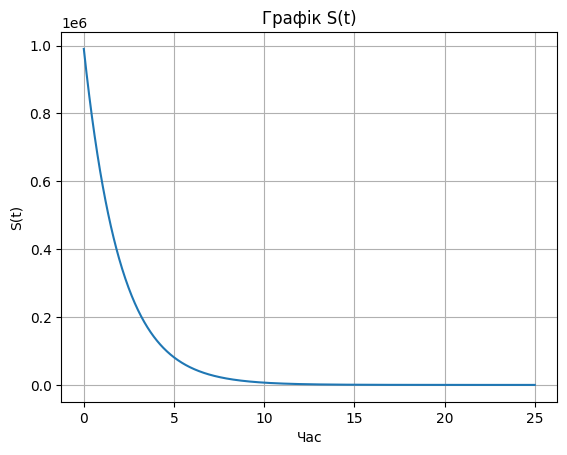

In [42]:
plt.plot(t, S)
plt.title("Графік S(t)")
plt.xlabel("Час")
plt.ylabel("S(t)")
plt.grid()
plt.show()

Будуємо графік кількості інфікованих індивідів I(t).

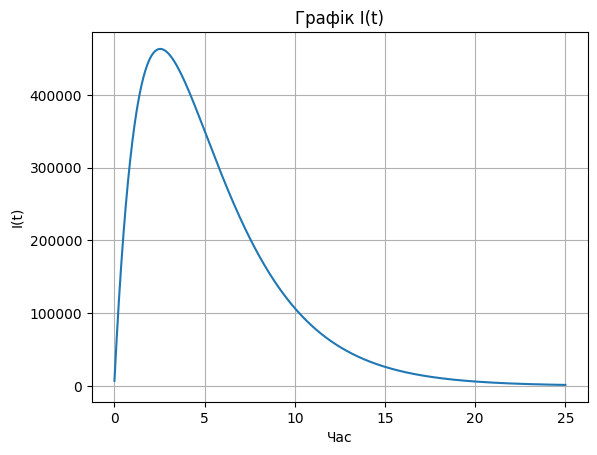

In [43]:
plt.plot(t, I)
plt.title("Графік I(t)")
plt.xlabel("Час")
plt.ylabel("I(t)")
plt.grid()
plt.show()

Використовуючи значення S(t) та I(t), знаходимо R(t) за формулою R(t) = N - S(t) - I(t).

In [44]:
R_from_formula = N - S - I

R_func = interp1d(t, R_from_formula, kind="cubic")
R_new = R_func(t)

Будуємо графік кількості людей, які одужали R(t).

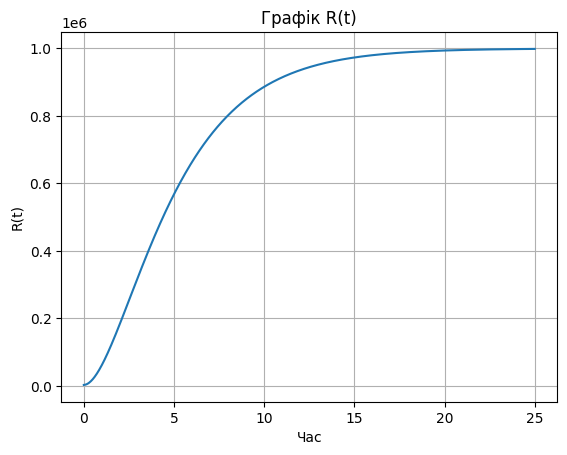

In [45]:
plt.plot(t, R_new)
plt.title("Графік R(t)")
plt.xlabel("Час")
plt.ylabel("R(t)")
plt.grid()
plt.show()

Будуємо всі три графіки S(t), I(t), R(t) на одній області відображення.

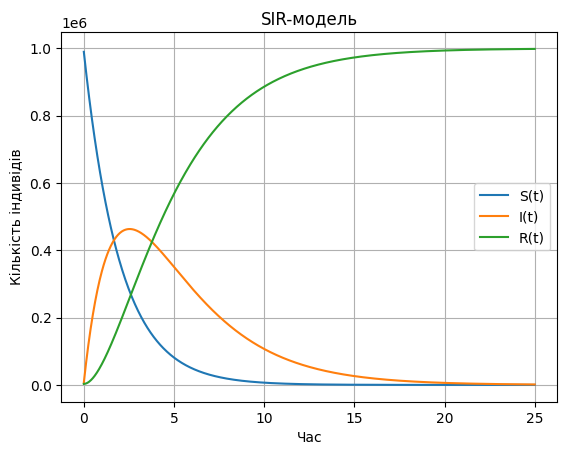

In [46]:
plt.plot(t, S, label="S(t)")
plt.plot(t, I, label="I(t)")
plt.plot(t, R_new, label="R(t)")

plt.title("SIR-модель")
plt.xlabel("Час")
plt.ylabel("Кількість індивідів")
plt.legend()
plt.grid()
plt.show()

Знаходимо параметри рівнянь S(t) та I(t) методом найменших квадратів.

In [47]:
def S_func(t, S0_fit, alpha_fit):
    return S0_fit * np.exp(-alpha_fit * t)

def I_func(t, I0_fit, alpha_fit, beta_fit):
    return (I0_fit + alpha_fit * S0 * t) * np.exp(-beta_fit * t)

params_S, _ = curve_fit(S_func, t, S)
params_I, _ = curve_fit(I_func, t, I)

print("Параметри для S(t):", params_S)
print("Параметри для I(t):", params_I)

Параметри для S(t): [9.9e+05 5.0e-01]
Параметри для I(t): [1.69823132e+04 4.76681549e-01 3.80918683e-01]


/tmp/ipykernel_2449/271381308.py:2: RuntimeWarning: overflow encountered in exp
  return S0_fit * np.exp(-alpha_fit * t)
/tmp/ipykernel_2449/271381308.py:2: RuntimeWarning: overflow encountered in multiply
  return S0_fit * np.exp(-alpha_fit * t)


Знаходимо момент часу, коли кількість інфікованих є максимальною.

In [48]:
I_func_interp = interp1d(t, I, kind="cubic")

maximum = minimize_scalar(lambda x: -I_func_interp(x), bounds=(0, 25), method="bounded")

t_max = maximum.x
I_max = I_func_interp(t_max)

print("Час максимуму:", t_max)
print("Максимальна кількість інфікованих:", I_max)

Час максимуму: 2.540006671430665
Максимальна кількість інфікованих: 463370.6307132838
